# Flight Delay Baseline Model and Hyperparameter Tuning

This notebook reads the existing model ready Parquet datasets, builds a majority-class benchmark, trains and evaluates the first SageMaker XGBoost model, and runs an optional six-job tuning experiment. The tuned model is evaluated separately before deciding whether to keep it. Run cells in order in a SageMaker Jupyter kernel with access to the project's Athena tables and S3 bucket. Managed training and Batch Transform use AWS resources.
Run from a fresh Jupyter kernel after downloading this version so the engine settings take effect before any AWS Wrangler query.


In [1]:
import os
# The lab currently provides SageMaker SDK v2. This SDK-supported setting
# silences its migration notice; managed jobs below use boto3 directly.
os.environ.setdefault("SAGEMAKER_SUPPRESS_V2_WARNING", "1")

import boto3
import awswrangler as wr
import pandas as pd

# This notebook uses local pandas DataFrames. Avoid starting a Ray object store
# in the small-shared-memory Jupyter container.
wr.engine.set("python")
wr.memory_format.set("pandas")

# SageMaker Studio / notebook instances can discover their attached execution role.
# Outside SageMaker, set SAGEMAKER_ROLE_ARN in the Jupyter environment.
role_arn = os.environ.get("SAGEMAKER_ROLE_ARN")
if not role_arn:
    try:
        from sagemaker.core.helper.session_helper import get_execution_role
    except ImportError:
        from sagemaker import get_execution_role
    try:
        role_arn = get_execution_role()
    except Exception as exc:
        raise RuntimeError(
            "Cannot find a SageMaker execution role. Set SAGEMAKER_ROLE_ARN "
            "to the role ARN allowed to access this S3 bucket and run SageMaker."
        ) from exc
print("SageMaker execution role:", role_arn)

from IPython.display import display

region = boto3.Session().region_name or "us-east-1"
account_id = boto3.client("sts").get_caller_identity()["Account"]

athena_db = "aai540_group1"
athena_s3_output = (
    f"s3://aws-athena-query-results-{account_id}-{region}/"
)

required_tables = [
    "flight_delay_train_2025",
    "flight_delay_validation_2025",
    "flight_delay_test_2025",
    "flight_delay_production_2025"
]

for table in required_tables:
    exists = wr.catalog.does_table_exist(
        database=athena_db,
        table=table
    )
    print(f"{table}: {'AVAILABLE' if exists else 'MISSING'}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
SageMaker execution role: arn:aws:iam::944832759247:role/LabRole
flight_delay_train_2025: AVAILABLE
flight_delay_validation_2025: AVAILABLE
flight_delay_test_2025: AVAILABLE
flight_delay_production_2025: AVAILABLE


## Team Responsibility: Denis Mulabegovic
**Benchmark and Initial Model**

Covers the majority-class benchmark and the first machine learning model setup.


### Majority Class Benchmark

A simple majority class classifier is used as the benchmark. It predicts the most common training label for every flight. Accuracy, balanced accuracy, recall and F1 score are recorded so the trained model can later be evaluated against this baseline.

In [2]:
training_distribution = wr.athena.read_sql_query(
    """
    SELECT
        delayed,
        COUNT(*) AS records,
        ROUND(
            100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
            2
        ) AS percentage
    FROM flight_delay_train_2025
    GROUP BY delayed
    ORDER BY records DESC
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(training_distribution)

majority_class = int(training_distribution.iloc[0]["delayed"])

print("Majority class:", majority_class)
print(
    "Benchmark prediction:",
    "Delayed" if majority_class == 1 else "Not delayed"
)

,delayed,records,percentage
0,0,2214442,79.47
1,1,571908,20.53


Majority class: 0
Benchmark prediction: Not delayed


In [3]:
evaluation_counts = wr.athena.read_sql_query(
    """
    SELECT
        'Validation' AS dataset,
        COUNT(*) AS total_records,
        COUNT_IF(delayed = 0) AS actual_not_delayed,
        COUNT_IF(delayed = 1) AS actual_delayed
    FROM flight_delay_validation_2025

    UNION ALL

    SELECT
        'Test',
        COUNT(*),
        COUNT_IF(delayed = 0),
        COUNT_IF(delayed = 1)
    FROM flight_delay_test_2025
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(evaluation_counts)

,dataset,total_records,actual_not_delayed,actual_delayed
0,Test,612811,435799,177012
1,Validation,599472,430067,169405


In [4]:
benchmark_results = []

for _, row in evaluation_counts.iterrows():
    total = int(row["total_records"])
    negative = int(row["actual_not_delayed"])
    positive = int(row["actual_delayed"])

    if majority_class == 0:
        true_negative = negative
        false_negative = positive
        true_positive = 0
        false_positive = 0
    else:
        true_negative = 0
        false_negative = 0
        true_positive = positive
        false_positive = negative

    accuracy = (
        true_positive + true_negative
    ) / total

    recall = (
        true_positive / (true_positive + false_negative)
        if true_positive + false_negative > 0
        else 0
    )

    precision = (
        true_positive / (true_positive + false_positive)
        if true_positive + false_positive > 0
        else 0
    )

    specificity = (
        true_negative / (true_negative + false_positive)
        if true_negative + false_positive > 0
        else 0
    )

    balanced_accuracy = (recall + specificity) / 2

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    benchmark_results.append({
        "dataset": row["dataset"],
        "accuracy": round(accuracy, 4),
        "balanced_accuracy": round(balanced_accuracy, 4),
        "delayed_precision": round(precision, 4),
        "delayed_recall": round(recall, 4),
        "delayed_f1": round(f1, 4)
    })

benchmark_results = pd.DataFrame(benchmark_results)

display(benchmark_results)

,dataset,accuracy,balanced_accuracy,delayed_precision,delayed_recall,delayed_f1
0,Test,0.7111,0.5,0,0.0,0
1,Validation,0.7174,0.5,0,0.0,0


## First Machine Learning Model

The first trained model will use SageMaker XGBoost with numerical features that are available before departure. This provides a reproducible first model while avoiding target leakage. Its validation and test performance will be compared against the majority class benchmark.

In [5]:
target_column = "delayed"

model_features = [
    "month",
    "day_of_month",
    "day_of_week",
    "is_weekend",
    "scheduled_departure_hour",
    "scheduled_arrival_hour",
    "scheduled_duration",
    "distance"
]

print("Target:", target_column)
print("Model features:", model_features)
print("Number of features:", len(model_features))

Target: delayed
Model features: ['month', 'day_of_month', 'day_of_week', 'is_weekend', 'scheduled_departure_hour', 'scheduled_arrival_hour', 'scheduled_duration', 'distance']
Number of features: 8


In [6]:
model_data_check = wr.athena.read_sql_query(
    """
    WITH modeling_data AS (
        SELECT
            'Training' AS dataset,
            month,
            day_of_month,
            day_of_week,
            is_weekend,
            scheduled_departure_hour,
            scheduled_arrival_hour,
            scheduled_duration,
            distance,
            delayed
        FROM flight_delay_train_2025

        UNION ALL

        SELECT
            'Validation',
            month,
            day_of_month,
            day_of_week,
            is_weekend,
            scheduled_departure_hour,
            scheduled_arrival_hour,
            scheduled_duration,
            distance,
            delayed
        FROM flight_delay_validation_2025

        UNION ALL

        SELECT
            'Test',
            month,
            day_of_month,
            day_of_week,
            is_weekend,
            scheduled_departure_hour,
            scheduled_arrival_hour,
            scheduled_duration,
            distance,
            delayed
        FROM flight_delay_test_2025
    )

    SELECT
        dataset,
        COUNT(*) AS records,

        COUNT_IF(
            month IS NULL
            OR day_of_month IS NULL
            OR day_of_week IS NULL
            OR is_weekend IS NULL
            OR scheduled_departure_hour IS NULL
            OR scheduled_arrival_hour IS NULL
            OR scheduled_duration IS NULL
            OR distance IS NULL
            OR delayed IS NULL
        ) AS incomplete_records,

        ROUND(
            100.0 * AVG(CAST(delayed AS DOUBLE)),
            2
        ) AS delay_rate_pct

    FROM modeling_data
    GROUP BY dataset
    ORDER BY dataset
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(model_data_check)

,dataset,records,incomplete_records,delay_rate_pct
0,Test,612811,0,28.89
1,Training,2786350,0,20.53
2,Validation,599472,0,28.26


## Team Responsibility: Thomas Geraci
**SageMaker Data Preparation and Model Training**

Covers preparing the data for SageMaker XGBoost and training the SageMaker model.


## Prepare Data for SageMaker XGBoost

The training and validation records will be exported from Athena to S3 in the format required by SageMaker XGBoost. The target column will appear first, followed by the eight numerical features.

In [7]:
model_bucket = f"sagemaker-aai540-modeling-{account_id}"
model_prefix = "flight-delay-xgboost"

train_s3_path = f"s3://{model_bucket}/{model_prefix}/data/train/"
validation_s3_path = f"s3://{model_bucket}/{model_prefix}/data/validation/"
test_s3_path = f"s3://{model_bucket}/{model_prefix}/data/test/"
model_output_path = f"s3://{model_bucket}/{model_prefix}/model-output/"

print("Model bucket:", model_bucket)
print("Training path:", train_s3_path)
print("Validation path:", validation_s3_path)
print("Test path:", test_s3_path)
print("Model output:", model_output_path)

Model bucket: sagemaker-aai540-modeling-944832759247
Training path: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/data/train/
Validation path: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/data/validation/
Test path: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/data/test/
Model output: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/model-output/


In [8]:
from botocore.exceptions import ClientError

s3_client = boto3.client("s3", region_name=region)

try:
    if region == "us-east-1":
        s3_client.create_bucket(Bucket=model_bucket)
    else:
        s3_client.create_bucket(
            Bucket=model_bucket,
            CreateBucketConfiguration={"LocationConstraint": region}
        )
    print("Modeling bucket created.")
except ClientError as error:
    error_code = error.response["Error"]["Code"]

    if error_code == "BucketAlreadyOwnedByYou":
        print("Modeling bucket already exists.")
    else:
        raise

s3_client.put_public_access_block(
    Bucket=model_bucket,
    PublicAccessBlockConfiguration={
        "BlockPublicAcls": True,
        "IgnorePublicAcls": True,
        "BlockPublicPolicy": True,
        "RestrictPublicBuckets": True
    }
)

s3_client.put_bucket_encryption(
    Bucket=model_bucket,
    ServerSideEncryptionConfiguration={
        "Rules": [
            {
                "ApplyServerSideEncryptionByDefault": {
                    "SSEAlgorithm": "AES256"
                }
            }
        ]
    }
)

print("Public access blocked.")
print("SSE-S3 encryption enabled.")
print("Modeling bucket ready:", model_bucket)

Modeling bucket created.
Public access blocked.
SSE-S3 encryption enabled.
Modeling bucket ready: sagemaker-aai540-modeling-944832759247


In [9]:
export_datasets = {
    "Training": (
        "flight_delay_train_2025",
        train_s3_path
    ),
    "Validation": (
        "flight_delay_validation_2025",
        validation_s3_path
    ),
    "Test": (
        "flight_delay_test_2025",
        test_s3_path
    )
}

ordered_columns = [target_column] + model_features
select_columns = ",\n        ".join(ordered_columns)

for dataset_name, (table_name, output_path) in export_datasets.items():
    existing_files = wr.s3.list_objects(output_path)

    if existing_files:
        print(
            f"{dataset_name}: export already exists "
            f"({len(existing_files)} files). Skipping."
        )
        continue

    export_query = f"""
    UNLOAD (
        SELECT
            {select_columns}
        FROM "{athena_db}"."{table_name}"
    )
    TO '{output_path}'
    WITH (
        format = 'TEXTFILE',
        field_delimiter = ','
    )
    """

    print(f"Exporting {dataset_name} data...")

    wr.athena.start_query_execution(
        sql=export_query,
        database=athena_db,
        s3_output=athena_s3_output,
        wait=True
    )

    exported_files = wr.s3.list_objects(output_path)

    print(
        f"{dataset_name}: complete "
        f"({len(exported_files)} files)"
    )

print("All modeling datasets are ready.")

Training: export already exists (1 files). Skipping.
Validation: export already exists (1 files). Skipping.
Test: export already exists (1 files). Skipping.
All modeling datasets are ready.


In [10]:
import gzip
import io

export_summary = []

for dataset_name, (_, s3_path) in export_datasets.items():
    files = wr.s3.list_objects(s3_path)
    file_path = files[0]

    bucket_name, object_key = file_path.replace(
        "s3://", ""
    ).split("/", 1)

    object_info = s3_client.head_object(
        Bucket=bucket_name,
        Key=object_key
    )

    response = s3_client.get_object(
        Bucket=bucket_name,
        Key=object_key
    )

    with gzip.GzipFile(fileobj=response["Body"]) as compressed_file:
        sample_lines = [
            compressed_file.readline().decode("utf-8")
            for _ in range(5)
        ]

    sample = pd.read_csv(
        io.StringIO("".join(sample_lines)),
        header=None,
        names=ordered_columns
    )

    export_summary.append({
        "dataset": dataset_name,
        "files": len(files),
        "size_mb": round(
            object_info["ContentLength"] / (1024 ** 2),
            2
        ),
        "columns": sample.shape[1]
    })

    print(f"\n{dataset_name} sample:")
    display(sample)

export_summary = pd.DataFrame(export_summary)
display(export_summary)


Training sample:


,delayed,month,day_of_month,day_of_week,is_weekend,scheduled_departure_hour,scheduled_arrival_hour,scheduled_duration,distance
0,0,2,12,3,0,19,20,192.0,1055.0
1,0,2,12,3,0,21,5,263.0,2106.0
2,1,2,12,3,0,5,6,77.0,447.0
3,0,2,12,3,0,16,19,200.0,1237.0
4,0,2,12,3,0,20,23,217.0,1237.0



Validation sample:


,delayed,month,day_of_month,day_of_week,is_weekend,scheduled_departure_hour,scheduled_arrival_hour,scheduled_duration,distance
0,1,6,10,2,0,7,9,276.0,1888.0
1,0,6,10,2,0,17,23,229.0,1590.0
2,0,6,10,2,0,17,21,242.0,1391.0
3,0,6,10,2,0,12,17,243.0,1391.0
4,0,6,10,2,0,7,10,228.0,1389.0



Test sample:


,delayed,month,day_of_month,day_of_week,is_weekend,scheduled_departure_hour,scheduled_arrival_hour,scheduled_duration,distance
0,0,7,10,4,0,9,10,80.0,338.0
1,1,7,10,4,0,20,23,140.0,909.0
2,1,7,10,4,0,13,15,85.0,358.0
3,0,7,10,4,0,17,19,85.0,358.0
4,1,7,10,4,0,10,12,260.0,1791.0


,dataset,files,size_mb,columns
0,Training,1,15.04,9
1,Validation,1,3.23,9
2,Test,1,3.31,9


## Train the SageMaker XGBoost Model

A managed SageMaker training job will train an XGBoost binary classifier. Class weighting will be used because delayed flights are less common than non delayed flights.

In [11]:
from datetime import datetime, timezone

try:
    from sagemaker.core import image_uris
except ImportError:
    from sagemaker import image_uris

sagemaker_client = boto3.client(
    "sagemaker",
    region_name=region
)

xgboost_image_uri = image_uris.retrieve(
    "xgboost",
    region,
    "1.7-1"
)

training_job_name = (
    "flight-delay-xgboost-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

negative_records = 2214442
positive_records = 571908

scale_pos_weight = round(
    negative_records / positive_records,
    2
)

hyperparameters = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "max_depth": "5",
    "eta": "0.1",
    "min_child_weight": "1",
    "subsample": "0.8",
    "colsample_bytree": "0.8",
    "scale_pos_weight": str(scale_pos_weight),
    "num_round": "200",
    "early_stopping_rounds": "20"
}

print("Training job:", training_job_name)
print("XGBoost image:", xgboost_image_uri)
print("Execution role:", role_arn)
print("Instance type: ml.m5.large")
print("Class weight:", scale_pos_weight)
print("Hyperparameters:", hyperparameters)

Training job: flight-delay-xgboost-20260925-162307
XGBoost image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1
Execution role: arn:aws:iam::944832759247:role/LabRole
Instance type: ml.m5.large
Class weight: 3.87
Hyperparameters: {'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'max_depth': '5', 'eta': '0.1', 'min_child_weight': '1', 'subsample': '0.8', 'colsample_bytree': '0.8', 'scale_pos_weight': '3.87', 'num_round': '200', 'early_stopping_rounds': '20'}


In [12]:
import gzip
import os
import shutil
import tempfile

compressed_paths = {
    "train": (
        f"s3://{model_bucket}/{model_prefix}/data/train/"
    ),
    "validation": (
        f"s3://{model_bucket}/{model_prefix}/data/validation/"
    ),
    "test": (
        f"s3://{model_bucket}/{model_prefix}/data/test/"
    )
}

uncompressed_paths = {
    "train": (
        f"s3://{model_bucket}/{model_prefix}/"
        "data-uncompressed/train/"
    ),
    "validation": (
        f"s3://{model_bucket}/{model_prefix}/"
        "data-uncompressed/validation/"
    ),
    "test": (
        f"s3://{model_bucket}/{model_prefix}/"
        "data-uncompressed/test/"
    )
}

for dataset_name, source_prefix in compressed_paths.items():
    destination_prefix = uncompressed_paths[dataset_name]
    existing_files = wr.s3.list_objects(destination_prefix)

    if existing_files:
        print(
            f"{dataset_name}: uncompressed file already exists. "
            "Skipping."
        )
        continue

    source_path = wr.s3.list_objects(source_prefix)[0]

    source_bucket, source_key = source_path.replace(
        "s3://", ""
    ).split("/", 1)

    destination_key = (
        f"{model_prefix}/data-uncompressed/"
        f"{dataset_name}/data.csv"
    )

    print(f"Preparing {dataset_name} data...")

    with tempfile.TemporaryDirectory() as temporary_directory:
        compressed_file = os.path.join(
            temporary_directory,
            "data.gz"
        )

        uncompressed_file = os.path.join(
            temporary_directory,
            "data.csv"
        )

        s3_client.download_file(
            source_bucket,
            source_key,
            compressed_file
        )

        with gzip.open(compressed_file, "rb") as source:
            with open(uncompressed_file, "wb") as destination:
                shutil.copyfileobj(
                    source,
                    destination,
                    length=16 * 1024 * 1024
                )

        s3_client.upload_file(
            uncompressed_file,
            model_bucket,
            destination_key,
            ExtraArgs={
                "ServerSideEncryption": "AES256",
                "ContentType": "text/csv"
            }
        )

    destination_info = s3_client.head_object(
        Bucket=model_bucket,
        Key=destination_key
    )

    size_mb = round(
        destination_info["ContentLength"] / (1024 ** 2),
        2
    )

    print(
        f"{dataset_name}: complete "
        f"({size_mb} MB uncompressed)"
    )

train_s3_path = uncompressed_paths["train"]
validation_s3_path = uncompressed_paths["validation"]
test_s3_path = uncompressed_paths["test"]

print("\nUpdated training path:", train_s3_path)
print("Updated validation path:", validation_s3_path)
print("Updated test path:", test_s3_path)

train: uncompressed file already exists. Skipping.
validation: uncompressed file already exists. Skipping.
test: uncompressed file already exists. Skipping.

Updated training path: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/data-uncompressed/train/
Updated validation path: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/data-uncompressed/validation/
Updated test path: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/data-uncompressed/test/


In [13]:
import time
from datetime import datetime, timezone

training_job_name = (
    "flight-delay-xgboost-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

training_response = sagemaker_client.create_training_job(
    TrainingJobName=training_job_name,
    AlgorithmSpecification={
        "TrainingImage": xgboost_image_uri,
        "TrainingInputMode": "File"
    },
    RoleArn=role_arn,
    InputDataConfig=[
        {
            "ChannelName": "train",
            "DataSource": {
                "S3DataSource": {
                    "S3DataType": "S3Prefix",
                    "S3Uri": train_s3_path,
                    "S3DataDistributionType": "FullyReplicated"
                }
            },
            "ContentType": "text/csv",
            "InputMode": "File"
        },
        {
            "ChannelName": "validation",
            "DataSource": {
                "S3DataSource": {
                    "S3DataType": "S3Prefix",
                    "S3Uri": validation_s3_path,
                    "S3DataDistributionType": "FullyReplicated"
                }
            },
            "ContentType": "text/csv",
            "InputMode": "File"
        }
    ],
    OutputDataConfig={
        "S3OutputPath": model_output_path
    },
    ResourceConfig={
        "InstanceType": "ml.m5.large",
        "InstanceCount": 1,
        "VolumeSizeInGB": 10
    },
    StoppingCondition={
        "MaxRuntimeInSeconds": 3600
    },
    HyperParameters=hyperparameters,
    Tags=[
        {
            "Key": "Project",
            "Value": "FlightDelayPrediction"
        },
        {
            "Key": "ModelType",
            "Value": "XGBoost"
        }
    ]
)

print("Training job submitted:", training_job_name)

previous_status = None

while True:
    training_description = (
        sagemaker_client.describe_training_job(
            TrainingJobName=training_job_name
        )
    )

    current_status = training_description["TrainingJobStatus"]

    if current_status != previous_status:
        print("Training status:", current_status)
        previous_status = current_status

    if current_status in {"Completed", "Failed", "Stopped"}:
        break

    time.sleep(20)

if current_status == "Completed":
    model_artifact = training_description[
        "ModelArtifacts"
    ]["S3ModelArtifacts"]

    print("Training completed successfully.")
    print("Model artifact:", model_artifact)
    print(
        "Training seconds:",
        training_description.get("TrainingTimeInSeconds")
    )
    print(
        "Billable seconds:",
        training_description.get("BillableTimeInSeconds")
    )
else:
    failure_reason = training_description.get(
        "FailureReason",
        "No failure reason returned."
    )

    raise RuntimeError(
        f"Training ended with status {current_status}: "
        f"{failure_reason}"
    )

Training job submitted: flight-delay-xgboost-20260925-162308
Training status: InProgress
Training status: Completed
Training completed successfully.
Model artifact: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/model-output/flight-delay-xgboost-20260925-162308/output/model.tar.gz
Training seconds: 210
Billable seconds: 210


## Team Responsibility: Daniel Sims
**Model Evaluation, Batch Deployment, and Feature Analysis**

Covers evaluating the trained model against the benchmark, SageMaker Batch Transform deployment, test-set evaluation, and feature importance.


### Evaluate the Trained Model

The trained XGBoost model will be evaluated on the July test dataset using SageMaker Batch Transform. The results will be compared with the majority class benchmark.

In [14]:
model_name = training_job_name

try:
    model_response = sagemaker_client.create_model(
        ModelName=model_name,
        PrimaryContainer={
            "Image": xgboost_image_uri,
            "ModelDataUrl": model_artifact
        },
        ExecutionRoleArn=role_arn,
        Tags=[
            {
                "Key": "Project",
                "Value": "FlightDelayPrediction"
            }
        ]
    )

    print("SageMaker model created.")

except ClientError as error:
    error_message = error.response["Error"]["Message"]

    if "already existing" in error_message.lower():
        print("SageMaker model already exists.")
    else:
        raise

print("Model name:", model_name)
print("Model artifact:", model_artifact)

SageMaker model created.
Model name: flight-delay-xgboost-20260925-162308
Model artifact: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/model-output/flight-delay-xgboost-20260925-162308/output/model.tar.gz


In [15]:
import time
from datetime import datetime, timezone

transform_job_name = (
    "flight-delay-test-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

test_prediction_path = (
    f"s3://{model_bucket}/{model_prefix}/"
    f"predictions/test/{transform_job_name}/"
)

transform_response = sagemaker_client.create_transform_job(
    TransformJobName=transform_job_name,
    ModelName=model_name,
    BatchStrategy="MultiRecord",
    MaxConcurrentTransforms=1,
    MaxPayloadInMB=6,
    TransformInput={
        "DataSource": {
            "S3DataSource": {
                "S3DataType": "S3Prefix",
                "S3Uri": test_s3_path
            }
        },
        "ContentType": "text/csv",
        "SplitType": "Line"
    },
    TransformOutput={
        "S3OutputPath": test_prediction_path,
        "Accept": "text/csv",
        "AssembleWith": "Line"
    },
    TransformResources={
        "InstanceType": "ml.m5.large",
        "InstanceCount": 1
    },
    DataProcessing={
        "InputFilter": "$[1:]",
        "JoinSource": "Input",
        "OutputFilter": "$[0,-1]"
    },
    Tags=[
        {
            "Key": "Project",
            "Value": "FlightDelayPrediction"
        }
    ]
)

print("Batch transform submitted:", transform_job_name)

previous_status = None

while True:
    transform_description = (
        sagemaker_client.describe_transform_job(
            TransformJobName=transform_job_name
        )
    )

    current_status = transform_description["TransformJobStatus"]

    if current_status != previous_status:
        print("Transform status:", current_status)
        previous_status = current_status

    if current_status in {
        "Completed",
        "Failed",
        "Stopped"
    }:
        break

    time.sleep(20)

if current_status == "Completed":
    prediction_files = wr.s3.list_objects(
        test_prediction_path
    )

    print("Batch transform completed successfully.")
    print("Prediction location:", test_prediction_path)
    print("Prediction files:", len(prediction_files))
else:
    failure_reason = transform_description.get(
        "FailureReason",
        "No failure reason returned."
    )

    raise RuntimeError(
        f"Transform ended with status {current_status}: "
        f"{failure_reason}"
    )

Batch transform submitted: flight-delay-test-20260925-162729
Transform status: InProgress
Transform status: Completed
Batch transform completed successfully.
Prediction location: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/predictions/test/flight-delay-test-20260925-162729/
Prediction files: 1


In [16]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

test_predictions = wr.s3.read_csv(
    path=test_prediction_path,
    header=None,
    names=["actual", "probability"]
)

test_predictions["actual"] = pd.to_numeric(
    test_predictions["actual"]
).astype(int)

test_predictions["probability"] = pd.to_numeric(
    test_predictions["probability"]
)

classification_threshold = 0.5

test_predictions["predicted"] = (
    test_predictions["probability"]
    >= classification_threshold
).astype(int)

actual = test_predictions["actual"]
predicted = test_predictions["predicted"]
probability = test_predictions["probability"]

model_metrics = {
    "model": "SageMaker XGBoost",
    "accuracy": accuracy_score(actual, predicted),
    "balanced_accuracy": balanced_accuracy_score(
        actual,
        predicted
    ),
    "delayed_precision": precision_score(
        actual,
        predicted,
        zero_division=0
    ),
    "delayed_recall": recall_score(
        actual,
        predicted,
        zero_division=0
    ),
    "delayed_f1": f1_score(
        actual,
        predicted,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(actual, probability),
    "pr_auc": average_precision_score(
        actual,
        probability
    )
}

benchmark_metrics = {
    "model": "Majority-Class Benchmark",
    "accuracy": accuracy_score(
        actual,
        [0] * len(actual)
    ),
    "balanced_accuracy": 0.5,
    "delayed_precision": 0.0,
    "delayed_recall": 0.0,
    "delayed_f1": 0.0,
    "roc_auc": 0.5,
    "pr_auc": actual.mean()
}

comparison_results = pd.DataFrame([
    benchmark_metrics,
    model_metrics
]).round(4)

print("Test records:", f"{len(test_predictions):,}")
print("Classification threshold:", classification_threshold)

display(test_predictions.head())
display(comparison_results)

confusion = confusion_matrix(actual, predicted)

confusion_results = pd.DataFrame(
    confusion,
    index=[
        "Actual Not Delayed",
        "Actual Delayed"
    ],
    columns=[
        "Predicted Not Delayed",
        "Predicted Delayed"
    ]
)

display(confusion_results)

Test records: 612,811
Classification threshold: 0.5


,actual,probability,predicted
0,0,0.406111,0
1,1,0.605511,1
2,1,0.510567,1
3,0,0.599081,1
4,1,0.446172,0


,model,accuracy,balanced_accuracy,delayed_precision,delayed_recall,delayed_f1,roc_auc,pr_auc
0,Majority-Class Benchmark,0.7111,0.5000,0.0000,0.000,0.0000,0.5000,0.2889
1,SageMaker XGBoost,0.6032,0.6418,0.3985,0.733,0.5163,0.6709,0.4000


,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,239908,195891
Actual Delayed,47257,129755


### Test Set Evaluation

Use the metric table and confusion matrix printed directly above for this run. The majority-class benchmark has no delayed-flight recall because it predicts every flight as not delayed. The trained XGBoost model identifies some delayed flights, with a tradeoff in overall accuracy. Results from earlier notebook runs can differ; do not use previously written numbers as the current result.

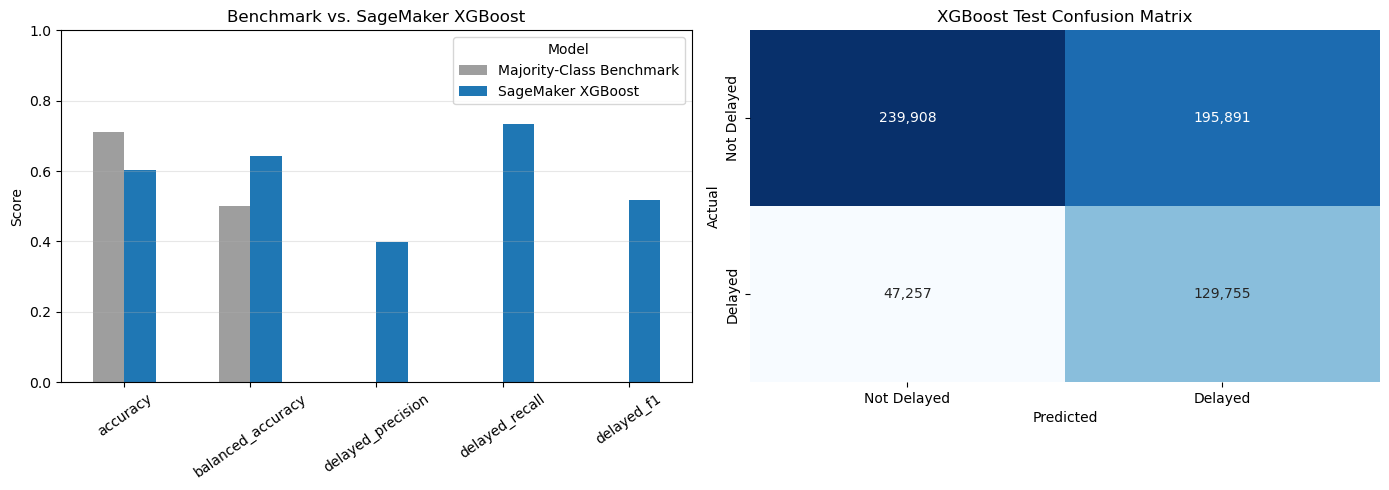

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "delayed_precision",
    "delayed_recall",
    "delayed_f1"
]

plot_data = comparison_results.set_index("model")[metric_names].T
plot_data.plot(kind="bar", ax=axes[0], color=["#9e9e9e", "#1f77b4"])

axes[0].set_title("Benchmark vs. SageMaker XGBoost")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Model")
axes[0].grid(axis="y", alpha=0.3)

sns.heatmap(
    confusion_matrix(
        test_predictions["actual"],
        test_predictions["predicted"]
    ),
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Delayed", "Delayed"],
    yticklabels=["Not Delayed", "Delayed"],
    ax=axes[1]
)

axes[1].set_title("XGBoost Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Feature Importance

The trained XGBoost model is inspected to determine which of the eight input
features contributed most to its predictions.

,feature,gain,importance_pct
4,scheduled_departure_hour,9864.96,48.24
5,scheduled_arrival_hour,4981.34,24.36
0,month,1836.47,8.98
1,day_of_month,1330.19,6.50
2,day_of_week,1087.69,5.32
3,is_weekend,676.28,3.31
7,distance,348.89,1.71
6,scheduled_duration,323.95,1.58


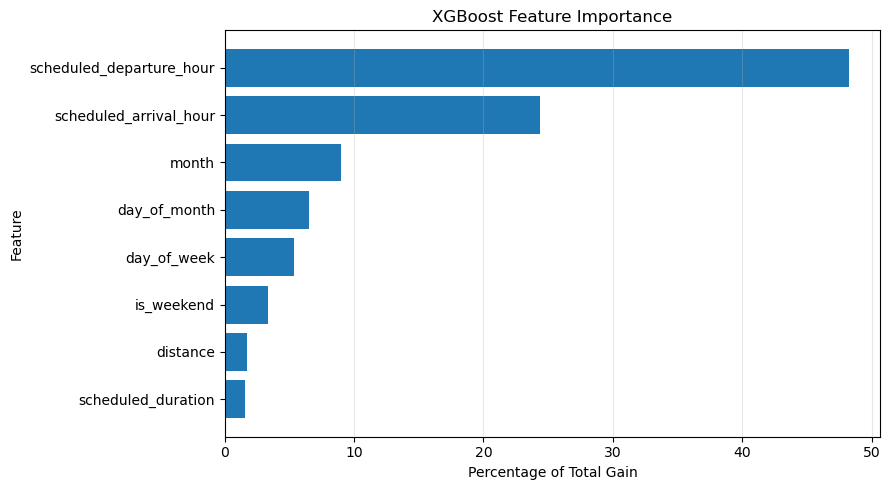

In [18]:
import os
import tarfile
import tempfile
from urllib.parse import urlparse

import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

artifact_uri = model_artifact
parsed_uri = urlparse(artifact_uri)

artifact_bucket = parsed_uri.netloc
artifact_key = parsed_uri.path.lstrip("/")

with tempfile.TemporaryDirectory() as temp_dir:
    artifact_file = os.path.join(temp_dir, "model.tar.gz")

    s3_client.download_file(
        artifact_bucket,
        artifact_key,
        artifact_file
    )

    with tarfile.open(artifact_file, "r:gz") as archive:
        archive.extractall(temp_dir, filter="data")

    extracted_files = [
        os.path.join(temp_dir, filename)
        for filename in os.listdir(temp_dir)
        if filename != "model.tar.gz"
    ]

    booster = xgb.Booster()

    for candidate_file in extracted_files:
        try:
            booster.load_model(candidate_file)
            model_file = candidate_file
            break
        except xgb.core.XGBoostError:
            continue
    else:
        raise FileNotFoundError("XGBoost model file was not found.")

raw_importance = booster.get_score(importance_type="gain")

feature_importance = {}

for feature_name, importance in raw_importance.items():
    if feature_name.startswith("f") and feature_name[1:].isdigit():
        feature_index = int(feature_name[1:])
        readable_name = model_features[feature_index]
    else:
        readable_name = feature_name

    feature_importance[readable_name] = importance

importance_df = (
    pd.DataFrame(
        feature_importance.items(),
        columns=["feature", "gain"]
    )
    .sort_values("gain", ascending=False)
)

importance_df["importance_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum() * 100
)

display(importance_df.round(2))

plt.figure(figsize=(9, 5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance_pct"][::-1],
    color="#1f77b4"
)
plt.title("XGBoost Feature Importance")
plt.xlabel("Percentage of Total Gain")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The chart and table above show feature importance for the model artifact created in this run. Review those values when discussing which scheduled-flight attributes contributed most; this section deliberately does not quote numbers from an earlier run. Importance describes the fitted model's use of a feature and does not establish causation.

## Team Responsibility: Thomas Geraci
**Hyperparameter tuning setup and training**

Run the existing notebook through the first model's evaluation before this section. This experiment keeps the original model and its S3 outputs. SageMaker will try **six** configurations, one at a time to fit common AWS Academy quotas, using the same training and validation files; it does **not** train on or select parameters using the test set. The objective is SageMaker's built-in `validation:auc` metric. We report PR AUC, F1, recall and balanced accuracy on the test set afterward as well. This tuning job uses managed instances and can incur charges; AWS Academy quotas and session time may restrict completion. Training job names and output paths are unique each run.

In [19]:
# Thomas: configure and submit a small managed SageMaker tuning job.
from datetime import datetime, timezone
import time

tuning_job_name = (
    "flight-tune-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)
tuning_model_output = (
    f"s3://{model_bucket}/{model_prefix}/tuning/model-output/{tuning_job_name}/"
)

def tuning_channel(name, path):
    return {
        "ChannelName": name,
        "DataSource": {
            "S3DataSource": {
                "S3DataType": "S3Prefix",
                "S3Uri": path,
                "S3DataDistributionType": "FullyReplicated"
            }
        },
        "ContentType": "text/csv",
        "InputMode": "File"
    }

# Keep the target-first, headerless CSV used by the original training job.
for name, path in (("train", train_s3_path),
                   ("validation", validation_s3_path)):
    if not wr.s3.list_objects(path):
        raise RuntimeError(f"Missing {name} data at {path}. Run data preparation first.")

tuning_response = sagemaker_client.create_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuning_job_name,
    HyperParameterTuningJobConfig={
        "Strategy": "Bayesian",
        "HyperParameterTuningJobObjective": {
            "Type": "Maximize", "MetricName": "validation:auc"
        },
        "ResourceLimits": {
            "MaxNumberOfTrainingJobs": 6,
            "MaxParallelTrainingJobs": 1,
            "MaxRuntimeInSeconds": 10800
        },
        "ParameterRanges": {
            "IntegerParameterRanges": [
                {"Name": "max_depth", "MinValue": "3", "MaxValue": "7"}
            ],
            "ContinuousParameterRanges": [
                {"Name": "min_child_weight", "MinValue": "1", "MaxValue": "8"},
                {"Name": "eta", "MinValue": "0.03", "MaxValue": "0.2"},
                {"Name": "subsample", "MinValue": "0.65", "MaxValue": "1.0"},
                {"Name": "colsample_bytree", "MinValue": "0.65", "MaxValue": "1.0"}
            ]
        }
    },
    TrainingJobDefinition={
        "StaticHyperParameters": {
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "num_round": "200",
            "early_stopping_rounds": "20",
            "scale_pos_weight": str(scale_pos_weight)
        },
        "AlgorithmSpecification": {
            "TrainingImage": xgboost_image_uri,
            "TrainingInputMode": "File"
        },
        "RoleArn": role_arn,
        "InputDataConfig": [
            tuning_channel("train", train_s3_path),
            tuning_channel("validation", validation_s3_path)
        ],
        "OutputDataConfig": {"S3OutputPath": tuning_model_output},
        "ResourceConfig": {
            "InstanceType": "ml.m5.large",
            "InstanceCount": 1,
            "VolumeSizeInGB": 10
        },
        "StoppingCondition": {"MaxRuntimeInSeconds": 3600}
    },
    Tags=[{"Key": "Project", "Value": "FlightDelayPrediction"}]
)
print("Tuning job submitted:", tuning_job_name)
print("Status:", tuning_response["HyperParameterTuningJobArn"])

Tuning job submitted: flight-tune-20260925-163254
Status: arn:aws:sagemaker:us-east-1:944832759247:hyper-parameter-tuning-job/flight-tune-20260925-163254


In [20]:
# Thomas: wait for completion and record the winning training job.
# If your AWS Academy session ends, set tuning_job_name to the printed name
# from the previous cell and rerun this cell in a new session.
previous_status = None
while True:
    tuning_description = sagemaker_client.describe_hyper_parameter_tuning_job(
        HyperParameterTuningJobName=tuning_job_name
    )
    status = tuning_description["HyperParameterTuningJobStatus"]
    if status != previous_status:
        print("Tuning status:", status)
        previous_status = status
    if status in {"Completed", "Failed", "Stopped"}:
        break
    time.sleep(30)

best_training = tuning_description.get("BestTrainingJob")
if not best_training:
    raise RuntimeError(
        f"No winning training job found (status {status}). "
        f"Reason: {tuning_description.get('FailureReason', 'See SageMaker job details.')}"
    )

best_training_job_name = best_training["TrainingJobName"]
best_training_description = sagemaker_client.describe_training_job(
    TrainingJobName=best_training_job_name
)
if best_training_description["TrainingJobStatus"] != "Completed":
    raise RuntimeError(f"Best training job is not complete: {best_training_job_name}")

tuned_artifact = best_training_description["ModelArtifacts"]["S3ModelArtifacts"]
print("Tuning status:", status)
print("Best training job:", best_training_job_name)
print("Validation objective:", best_training.get("FinalHyperParameterTuningJobObjectiveMetric"))
print("Best hyperparameters:", best_training_description["HyperParameters"])
print("Tuned model artifact:", tuned_artifact)

Tuning status: InProgress
Tuning status: Completed
Tuning status: Completed
Best training job: flight-tune-20260925-163254-006-16fea7ae
Validation objective: {'MetricName': 'validation:auc', 'Value': 0.6764900088310242}
Best hyperparameters: {'_tuning_objective_metric': 'validation:auc', 'colsample_bytree': '0.922783544780442', 'early_stopping_rounds': '20', 'eta': '0.12897033708474992', 'eval_metric': 'auc', 'max_depth': '4', 'min_child_weight': '6.9914192326562095', 'num_round': '200', 'objective': 'binary:logistic', 'scale_pos_weight': '3.87', 'subsample': '0.9242125535886716'}
Tuned model artifact: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/tuning/model-output/flight-tune-20260925-163254/flight-tune-20260925-163254-006-16fea7ae/output/model.tar.gz


## Team Responsibility: Daniel Sims
**Tuned model evaluation and comparison**

Create a separate SageMaker model from the winning artifact and run Batch Transform on the held-out test file. This leaves Denis's original model untouched. Compare the test metrics at the same 0.5 threshold; the validation AUC chooses the tuning winner, while the test metrics tell us whether the experiment actually helped. Do not adjust the search after seeing test results without reserving a new untouched test set.

In [21]:
# Daniel: create a distinct tuned model and run held-out test inference.
tuned_model_name = best_training_job_name
try:
    sagemaker_client.create_model(
        ModelName=tuned_model_name,
        PrimaryContainer={"Image": xgboost_image_uri,
                          "ModelDataUrl": tuned_artifact},
        ExecutionRoleArn=role_arn,
        Tags=[{"Key": "Project", "Value": "FlightDelayPrediction"}]
    )
    print("Created tuned SageMaker model:", tuned_model_name)
except ClientError as error:
    if error.response["Error"]["Code"] != "ValidationException" or        "already exist" not in error.response["Error"].get("Message", "").lower():
        raise
    print("Tuned model already exists:", tuned_model_name)

tuned_transform_name = (
    "flight-delay-tuned-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)
tuned_prediction_path = (
    f"s3://{model_bucket}/{model_prefix}/predictions/tuned-test/"
    f"{tuned_transform_name}/"
)
sagemaker_client.create_transform_job(
    TransformJobName=tuned_transform_name,
    ModelName=tuned_model_name,
    BatchStrategy="MultiRecord",
    MaxConcurrentTransforms=1,
    MaxPayloadInMB=6,
    TransformInput={
        "DataSource": {"S3DataSource": {"S3DataType": "S3Prefix",
                                        "S3Uri": test_s3_path}},
        "ContentType": "text/csv",
        "SplitType": "Line"
    },
    TransformOutput={
        "S3OutputPath": tuned_prediction_path,
        "Accept": "text/csv",
        "AssembleWith": "Line"
    },
    TransformResources={"InstanceType": "ml.m5.large", "InstanceCount": 1},
    DataProcessing={
        "InputFilter": "$[1:]",
        "JoinSource": "Input",
        "OutputFilter": "$[0,-1]"
    },
    Tags=[{"Key": "Project", "Value": "FlightDelayPrediction"}]
)
print("Tuned Batch Transform submitted:", tuned_transform_name)

previous_status = None
while True:
    tuned_transform = sagemaker_client.describe_transform_job(
        TransformJobName=tuned_transform_name
    )
    status = tuned_transform["TransformJobStatus"]
    if status != previous_status:
        print("Tuned transform status:", status)
        previous_status = status
    if status in {"Completed", "Failed", "Stopped"}:
        break
    time.sleep(20)

if status != "Completed":
    raise RuntimeError(
        f"Tuned transform ended {status}: "
        f"{tuned_transform.get('FailureReason', 'See SageMaker job details.')}"
    )
print("Tuned predictions:", tuned_prediction_path)

Created tuned SageMaker model: flight-tune-20260925-163254-006-16fea7ae
Tuned Batch Transform submitted: flight-delay-tuned-20260925-165432
Tuned transform status: InProgress
Tuned transform status: Completed
Tuned predictions: s3://sagemaker-aai540-modeling-944832759247/flight-delay-xgboost/predictions/tuned-test/flight-delay-tuned-20260925-165432/


In [22]:
# Daniel: compare all three models without retraining or overwriting V1.
tuned_files = [p for p in wr.s3.list_objects(tuned_prediction_path)
               if p.endswith(".out")]
if not tuned_files:
    raise RuntimeError(f"No Batch Transform .out files at {tuned_prediction_path}")

tuned_predictions = wr.s3.read_csv(
    path=tuned_files, header=None, names=["actual", "probability"]
)
tuned_predictions["actual"] = pd.to_numeric(
    tuned_predictions["actual"]
).astype(int)
tuned_predictions["probability"] = pd.to_numeric(
    tuned_predictions["probability"]
)
if tuned_predictions.isna().any().any():
    raise ValueError("Missing values in tuned predictions")
if len(tuned_predictions) != len(test_predictions):
    raise ValueError("Tuned and original test record counts differ")
if tuned_predictions["actual"].value_counts().to_dict() !=    test_predictions["actual"].value_counts().to_dict():
    raise ValueError("Tuned and original test label counts differ")

tuned_actual = tuned_predictions["actual"]
tuned_probability = tuned_predictions["probability"]
tuned_predicted = (tuned_probability >= classification_threshold).astype(int)
tuned_metrics = {
    "model": "Tuned SageMaker XGBoost",
    "accuracy": accuracy_score(tuned_actual, tuned_predicted),
    "balanced_accuracy": balanced_accuracy_score(tuned_actual, tuned_predicted),
    "delayed_precision": precision_score(tuned_actual, tuned_predicted, zero_division=0),
    "delayed_recall": recall_score(tuned_actual, tuned_predicted, zero_division=0),
    "delayed_f1": f1_score(tuned_actual, tuned_predicted, zero_division=0),
    "roc_auc": roc_auc_score(tuned_actual, tuned_probability),
    "pr_auc": average_precision_score(tuned_actual, tuned_probability)
}

tuning_comparison = pd.DataFrame(
    [benchmark_metrics, model_metrics, tuned_metrics]
).set_index("model").round(4)
display(tuning_comparison)

metric_differences = pd.Series({
    metric: tuned_metrics[metric] - model_metrics[metric]
    for metric in ("accuracy", "balanced_accuracy", "delayed_precision",
                   "delayed_recall", "delayed_f1", "roc_auc", "pr_auc")
})
print("Tuned minus initial XGBoost (positive means higher):")
display(metric_differences.round(4).to_frame("difference"))

pr_gain = metric_differences["pr_auc"]
print(f"Current-run PR AUC: {model_metrics['pr_auc']:.4f} -> "
      f"{tuned_metrics['pr_auc']:.4f} (absolute change {pr_gain:+.4f}).")
print(f"Current-run accuracy: {model_metrics['accuracy']:.4f} -> "
      f"{tuned_metrics['accuracy']:.4f}.")
if 0 < pr_gain < 0.01:
    print("PR AUC rose slightly; this alone is not a compelling practical gain.")
elif pr_gain <= 0:
    print("PR AUC did not improve in this run.")
else:
    print("PR AUC increased; assess the other metrics before choosing a model.")
print("No model is automatically promoted. Keep V1 unless the selected metric "
      "and application tradeoffs justify switching.")
print("The original deployed SageMaker model remains:", model_name)
print("The tuned SageMaker model is available as:", tuned_model_name)

,accuracy,balanced_accuracy,delayed_precision,delayed_recall,delayed_f1,roc_auc,pr_auc
model,,,,,,,
Majority-Class Benchmark,0.7111,0.5000,0.0000,0.0000,0.0000,0.5000,0.2889
SageMaker XGBoost,0.6032,0.6418,0.3985,0.7330,0.5163,0.6709,0.4000
Tuned SageMaker XGBoost,0.6031,0.6406,0.3979,0.7292,0.5149,0.6736,0.4067


Tuned minus initial XGBoost (positive means higher):


,difference
accuracy,-0.0001
balanced_accuracy,-0.0012
delayed_precision,-0.0005
delayed_recall,-0.0038
delayed_f1,-0.0014
roc_auc,0.0026
pr_auc,0.0067


Current-run PR AUC: 0.4000 -> 0.4067 (absolute change +0.0067).
Current-run accuracy: 0.6032 -> 0.6031.
PR AUC rose slightly; this alone is not a compelling practical gain.
No model is automatically promoted. Keep V1 unless the selected metric and application tradeoffs justify switching.
The original deployed SageMaker model remains: flight-delay-xgboost-20260925-162308
The tuned SageMaker model is available as: flight-tune-20260925-163254-006-16fea7ae


### Interpretation and handoff

Thomas records the tuning job name, winning training job, validation objective, and selected hyperparameters. Daniel reviews the displayed comparison and explains any tradeoff in accuracy, delayed recall, F1, ROC AUC and PR AUC. Small changes should not be described as a substantial improvement. Retain the original model until the team explicitly chooses to use the separate tuned model.